In [9]:
import wave
import numpy as np
import matplotlib.pyplot as plt
import pyaudio
import os
import serial
import time
import threading
from scipy import signal

plt.close('all')

def grabar_audio(nombre_archivo, tasa_muestreo, tamano_bloque, tiempo_grabacion, formato, canales):
    audio = pyaudio.PyAudio()
    print("Dispositivos disponibles:")
    for i in range(audio.get_device_count()):
        info = audio.get_device_info_by_index(i)
        print(f"ID: {i}, Nombre: {info['name']}")
    index_selected = int(input("Introduce el ID del micrófono a utilizar: "))

    try:
        flujo_sonido = audio.open(format=formato, channels=canales, rate=tasa_muestreo,
                                  input=True, frames_per_buffer=tamano_bloque, input_device_index=index_selected)
        print('Inicia la grabación')
        datos_audio = []
        fragmentos = []
        for i in range(0, int(tasa_muestreo / tamano_bloque * tiempo_grabacion)):
            datos_bloque = flujo_sonido.read(tamano_bloque)
            datos_audio.append(datos_bloque)
            fragmentos.append(np.frombuffer(datos_bloque, dtype=np.int16))
        senal_audio = np.hstack(fragmentos)
        if np.max(np.abs(senal_audio)) != 0:
            senal_audio = senal_audio / np.max(np.abs(senal_audio)) * 32767
            senal_audio = senal_audio.astype(np.int16)

        print('Termina la Grabación')
        flujo_sonido.stop_stream()
        flujo_sonido.close()
    finally:
        audio.terminate()

    archivo_wave = wave.open(nombre_archivo, 'wb')
    archivo_wave.setnchannels(canales)
    archivo_wave.setsampwidth(audio.get_sample_size(formato))
    archivo_wave.setframerate(tasa_muestreo)
    archivo_wave.writeframes(b''.join([senal_audio.tobytes()]))
    archivo_wave.close()
    return senal_audio

def cargar_audio(file_path):
    FS=int(44100/25)
    with wave.open(file_path, 'rb') as wav_file:
        params = wav_file.getparams()
        _, sample_width, frame_rate, n_frames, _, _ = params[:6]
        frames = wav_file.readframes(n_frames)
    if sample_width==2:
        dtype=np.int16
    elif sample_width==3:
        dtype=np.int32
    data = np.frombuffer(frames, dtype=dtype)
    if frame_rate != FS:
        rr=FS/frame_rate
        frame_rate=FS
        data=signal.resample(data,int(len(data)*rr))
    return data, frame_rate

def leer_mensajes_arduino(arduino):
    while True:
        try:
            if arduino.in_waiting > 0:
                mensaje = arduino.readline().decode(errors='ignore').strip()
                print("Mensaje desde Arduino:", mensaje)
        except serial.SerialException as e:
            print(f"Error al leer desde Arduino: {e}")
            break
        except UnicodeDecodeError as e:
            print(f"Error de decodificación: {e}")
            continue

def enviar_vector_arduino(vector,step, win_len,n_windows, arduino):
    # arduino = serial.Serial(puerto, baudrate)
    # time.sleep(2) 

    hilo_lectura = threading.Thread(target=leer_mensajes_arduino, args=(arduino,))
    hilo_lectura.daemon = True 
    hilo_lectura.start()

    print("Enviando datos al Arduino...")
    param = f"{step},{win_len},{n_windows}\n"
    print(f"Parámetros enviados: {param}")
    
    if  arduino.readline().decode().strip()=="1":
        for idx,valor in enumerate(vector):
            print(f"{idx}:{valor}")
            arduino.write(f"{valor}\n".encode())  
            # time.sleep(0.1) 
    else: 
        arduino.write(param.encode())

    arduino.write(f"000\n".encode())
    print("Datos enviados correctamente. Esperando respuesta del Arduino...")

    while True:
        if arduino.in_waiting > 0:
            respuesta = arduino.readline().decode().strip()
            print("Respuesta del Arduino:", respuesta)
            break

def preenfasis_y_graficos(senal, tasa_muestreo, threshold=0.02, alpha=0.95):
    senal_normal = senal / np.max(np.abs(senal))   
    if len(senal_normal.shape) > 1:
        senal_normal = senal_normal[:, 0]
    pre = np.roll(senal_normal, 1) - alpha * senal_normal
    pre[0] = 0
    pre = np.where(np.abs(pre) >= 0.7, 0, pre)
    
    active_idx = np.where(np.abs(pre) > threshold)[0]
    if len(active_idx) > 0:
        start_idx = active_idx[0]
        end_idx = active_idx[-1]
        pre_trimmed = pre[start_idx:end_idx + 1]
    else:
        pre_trimmed = pre
    print(len(pre_trimmed))
    duration = len(pre) / tasa_muestreo
    time = np.linspace(0, duration, len(pre))
    time_trimmed = np.linspace(start_idx / tasa_muestreo, end_idx / tasa_muestreo, len(pre_trimmed))
    win_dur=0.02
    win_len=int(win_dur*tasa_muestreo)
    step=win_len
    n_windows=int(np.ceil((len(pre_trimmed)-win_len)/step))+1
    # pad_len=n_windows*step+win_len
    # test_sig_pad=np.append(pre_trimmed,np.zeros(pad_len-len(pre_trimmed)))
    enviar_vector_arduino(pre_trimmed,step, win_len,n_windows,arduino)

    plt.figure(figsize=(10, 5))
    plt.subplot(3, 1, 1)
    plt.plot(time, senal_normal)
    plt.title('Señal normalizada')
    plt.xlabel('Tiempo [s]')
    plt.ylabel('Amplitud')

    plt.subplot(3, 1, 2)
    plt.plot(time, pre)
    plt.title('Señal pre enfasis')
    plt.xlabel('Tiempo [s]')
    plt.ylabel('Amplitud')

    plt.subplot(3, 1, 3)
    plt.plot(time_trimmed, pre_trimmed)
    plt.title('Señal Recortada')
    plt.xlabel('Tiempo [s]')
    plt.ylabel('Amplitud')

    plt.tight_layout()
    # plt.show()

# Menú principal
while True:
    print("\nSelecciona una opción:")
    print("0. Vincular arduino")
    print("1. Grabar audio en tiempo real")
    print("2. Cargar archivo de audio pregrabado")
    print("3. Salir")
    opcion = input("Opción: ")

    if opcion == "0":
        arduino.close()
        try:
            arduino = serial.Serial('COM16', 115200)#, timeout=1)
            time.sleep(2) 
            # arduino.close()
            print("Conexión Exitosa...")
        except serial.SerialException as e:
            print(f"Error al comunicarse con el Arduino: {e}")
        
    elif opcion == "1":
        print("Grabando audio...")
        nombre_archivo = 'audio_grabado.wav'
        formato = pyaudio.paInt16
        canales = 1
        tasa_muestreo = int(44100/25)
        tamano_bloque = 1024
        tiempo_grabacion = 2
        senal = grabar_audio(nombre_archivo, tasa_muestreo, tamano_bloque, tiempo_grabacion, formato, canales)
        preenfasis_y_graficos(senal, tasa_muestreo)
    elif opcion == "2":
        file_path = input("Introduce la ruta del archivo WAV: ").strip().strip('"')
        if os.path.exists(file_path):
            senal, tasa_muestreo = cargar_audio(file_path)
            preenfasis_y_graficos(senal, tasa_muestreo)
        else:
            print("El archivo no existe. Intenta de nuevo.")
    elif opcion == "3":
        arduino.close()
        print("Saliendo...")
        break
    else:
        print("Opción no válida. Intenta de nuevo.")



Selecciona una opción:
0. Vincular arduino
1. Grabar audio en tiempo real
2. Cargar archivo de audio pregrabado
3. Salir
Conexión Exitosa...

Selecciona una opción:
0. Vincular arduino
1. Grabar audio en tiempo real
2. Cargar archivo de audio pregrabado
3. Salir
Saliendo...



Selecciona una opción:
0. Vincular Arduino
1. Grabar audio en tiempo real
2. Cargar archivo de audio pregrabado
3. Salir
Error al conectar con Arduino: could not open port 'COM16': OSError(22, 'The semaphore timeout period has expired.', None, 121)

Selecciona una opción:
0. Vincular Arduino
1. Grabar audio en tiempo real
2. Cargar archivo de audio pregrabado
3. Salir
El archivo no existe. Intenta de nuevo.

Selecciona una opción:
0. Vincular Arduino
1. Grabar audio en tiempo real
2. Cargar archivo de audio pregrabado
3. Salir
Error al conectar con Arduino: could not open port 'COM16': OSError(22, 'The semaphore timeout period has expired.', None, 121)

Selecciona una opción:
0. Vincular Arduino
1. Grabar audio en tiempo real
2. Cargar archivo de audio pregrabado
3. Salir
Error al conectar con Arduino: could not open port 'COM16': OSError(22, 'The semaphore timeout period has expired.', None, 121)

Selecciona una opción:
0. Vincular Arduino
1. Grabar audio en tiempo real
2. Cargar arc

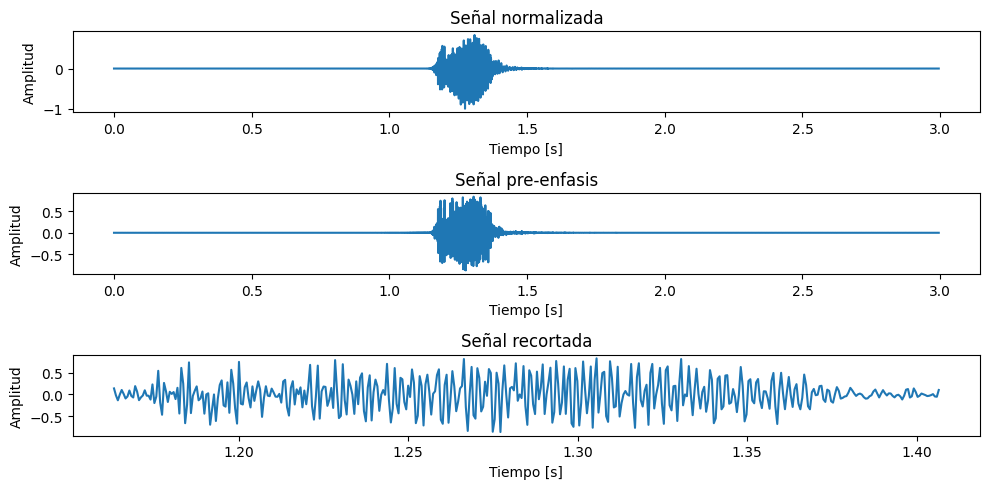


Selecciona una opción:
0. Vincular Arduino
1. Grabar audio en tiempo real
2. Cargar archivo de audio pregrabado
3. Salir
El archivo no existe. Intenta de nuevo.

Selecciona una opción:
0. Vincular Arduino
1. Grabar audio en tiempo real
2. Cargar archivo de audio pregrabado
3. Salir
Grabando audio...
Dispositivos disponibles:
ID: 0, Nombre: Microsoft Sound Mapper - Input
ID: 1, Nombre: MicrÃ³fono (Realtek(R) Audio)
ID: 2, Nombre: Microphone (Iriun Webcam)
ID: 3, Nombre: MicrÃ³fono (Steam Streaming Micr
ID: 4, Nombre: Microsoft Sound Mapper - Output
ID: 5, Nombre: Altavoces (Realtek(R) Audio)
ID: 6, Nombre: Altavoces (Steam Streaming Micr
ID: 7, Nombre: Altavoces (Steam Streaming Spea
ID: 8, Nombre: Primary Sound Capture Driver
ID: 9, Nombre: MicrÃ³fono (Realtek(R) Audio)
ID: 10, Nombre: Microphone (Iriun Webcam)
ID: 11, Nombre: MicrÃ³fono (Steam Streaming Microphone)
ID: 12, Nombre: Primary Sound Driver
ID: 13, Nombre: Altavoces (Realtek(R) Audio)
ID: 14, Nombre: Altavoces (Steam Strea

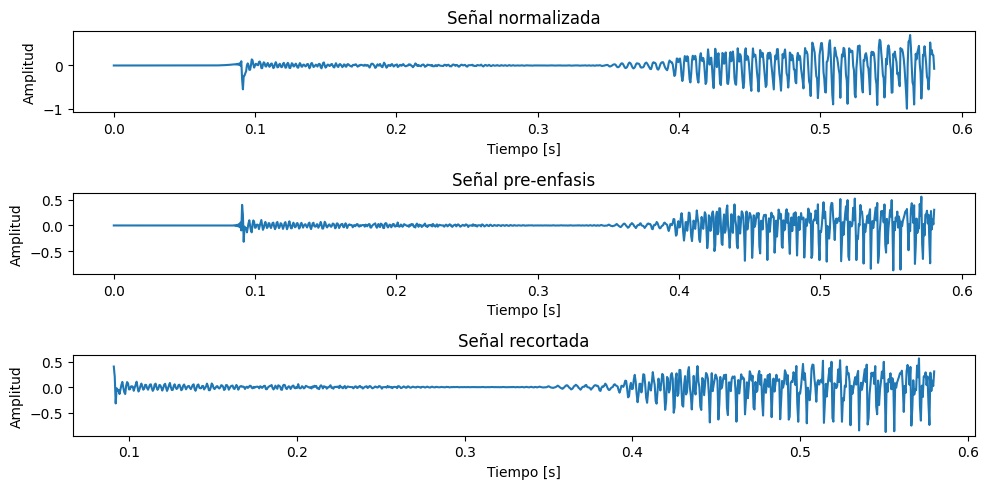


Selecciona una opción:
0. Vincular Arduino
1. Grabar audio en tiempo real
2. Cargar archivo de audio pregrabado
3. Salir
Enviando parámetros: 35,35,13

Respuesta del Arduino: 1
Parámetros aceptados. Enviando datos...
Señal del Arduino: 3
Enviado 0: 0.13926948430732178
Señal del Arduino: 3
Enviado 1: -0.02115031248628474
Señal del Arduino: 3
Enviado 2: -0.1349940334370506
Señal del Arduino: 3
Enviado 3: -0.0033219655149700766
Señal del Arduino: 3
Enviado 4: 0.10318624922854859
Señal del Arduino: 3
Enviado 5: 0.013429277165988546
Señal del Arduino: 3
Enviado 6: -0.09309672079945916
Señal del Arduino: 3
Enviado 7: -0.04736151084789435
Señal del Arduino: 3
Enviado 8: 0.0907073172160149
Señal del Arduino: 3
Enviado 9: -0.03451170441775223
Señal del Arduino: 3
Enviado 10: -0.07035903312611277
Señal del Arduino: 3
Enviado 11: 0.19228395071211368
Señal del Arduino: 3
Enviado 12: 0.06670763675618037
Señal del Arduino: 3
Enviado 13: -0.13228476163403496
Señal del Arduino: 3
Enviado 14: -0.06803

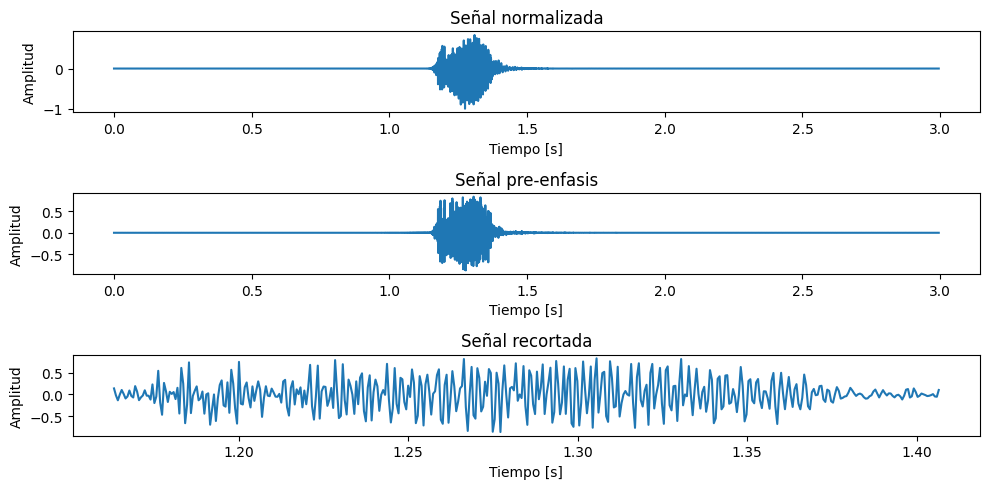


Selecciona una opción:
0. Vincular Arduino
1. Grabar audio en tiempo real
2. Cargar archivo de audio pregrabado
3. Salir
Enviando parámetros: 35,35,13

Respuesta del Arduino: 1
Parámetros aceptados. Enviando datos...
Señal del Arduino: 3
Enviado 0: 0.13926948430732178
Señal del Arduino: 3
Enviado 1: -0.02115031248628474
Señal del Arduino: 3
Enviado 2: -0.1349940334370506
Señal del Arduino: 3
Enviado 3: -0.0033219655149700766
Señal del Arduino: 3
Enviado 4: 0.10318624922854859
Señal del Arduino: 3
Enviado 5: 0.013429277165988546
Señal del Arduino: 3
Enviado 6: -0.09309672079945916
Señal del Arduino: 3
Enviado 7: -0.04736151084789435
Señal del Arduino: 3
Enviado 8: 0.0907073172160149
Señal del Arduino: 3
Enviado 9: -0.03451170441775223
Señal del Arduino: 3
Enviado 10: -0.07035903312611277
Señal del Arduino: 3
Enviado 11: 0.19228395071211368
Señal del Arduino: 3
Enviado 12: 0.06670763675618037
Señal del Arduino: 3
Enviado 13: -0.13228476163403496
Señal del Arduino: 3
Enviado 14: -0.06803

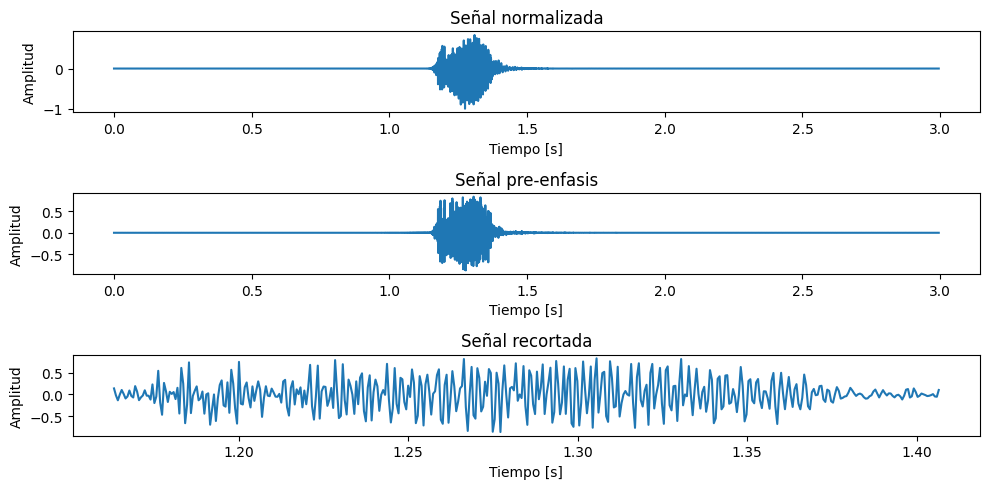


Selecciona una opción:
0. Vincular Arduino
1. Grabar audio en tiempo real
2. Cargar archivo de audio pregrabado
3. Salir
Saliendo...


In [2]:
import wave
import numpy as np
import matplotlib.pyplot as plt
import pyaudio
import os
import serial
import time
import threading
from scipy import signal

plt.close('all')

def grabar_audio(nombre_archivo, tasa_muestreo, tamano_bloque, tiempo_grabacion, formato, canales):
    audio = pyaudio.PyAudio()
    print("Dispositivos disponibles:")
    for i in range(audio.get_device_count()):
        info = audio.get_device_info_by_index(i)
        print(f"ID: {i}, Nombre: {info['name']}")
    index_selected = int(input("Introduce el ID del micrófono a utilizar: "))

    try:
        flujo_sonido = audio.open(format=formato, channels=canales, rate=tasa_muestreo,
                                  input=True, frames_per_buffer=tamano_bloque, input_device_index=index_selected)
        print('Inicia la grabación')
        datos_audio = []
        fragmentos = []
        for i in range(0, int(tasa_muestreo / tamano_bloque * tiempo_grabacion)):
            datos_bloque = flujo_sonido.read(tamano_bloque, exception_on_overflow=False)
            datos_audio.append(datos_bloque)
            fragmentos.append(np.frombuffer(datos_bloque, dtype=np.int16))
        senal_audio = np.hstack(fragmentos)
        print('Termina la Grabación')

        if np.max(np.abs(senal_audio)) != 0:
            senal_audio = senal_audio / np.max(np.abs(senal_audio)) * 32767
            senal_audio = senal_audio.astype(np.int16)

        flujo_sonido.stop_stream()
        flujo_sonido.close()
    except Exception as e:
        print(f"Error durante la grabación: {e}")
        return None
    finally:
        audio.terminate()

    try:
        with wave.open(nombre_archivo, 'wb') as archivo_wave:
            archivo_wave.setnchannels(canales)
            archivo_wave.setsampwidth(audio.get_sample_size(formato))
            archivo_wave.setframerate(tasa_muestreo)
            archivo_wave.writeframes(b''.join([senal_audio.tobytes()]))
    except Exception as e:
        print(f"Error al guardar el archivo WAV: {e}")
        return None

    return senal_audio

def cargar_audio(file_path):
    FS = int(44100/25)
    with wave.open(file_path, 'rb') as wav_file:
        params = wav_file.getparams()
        _, sample_width, frame_rate, n_frames, _, _ = params[:6]
        frames = wav_file.readframes(n_frames)
    dtype = np.int16 if sample_width == 2 else np.int32
    data = np.frombuffer(frames, dtype=dtype)
    if frame_rate != FS:
        rr = FS / frame_rate
        frame_rate = FS
        data = signal.resample(data, int(len(data) * rr))
    return data, frame_rate

def leer_mensajes_arduino(arduino):
    while True:
        try:
            if arduino.in_waiting > 0:
                mensaje = arduino.readline().decode('utf-8', errors='ignore').strip()
                print("Mensaje desde Arduino:", mensaje)
        except serial.SerialException as e:
            print(f"Error al leer desde Arduino: {e}")
            break
        except UnicodeDecodeError as e:
            print(f"Error de decodificación: {e}")
            continue

def enviar_vector_arduino(vector, step, win_len, n_windows, arduino):
    # Enviar parámetros al Arduino
    param = f"{step},{win_len},{n_windows}\n"
    print(f"Enviando parámetros: {param}")
    arduino.write(param.encode())

    # Esperar confirmación
    start_time = time.time()
    while time.time() - start_time < 5:  # 5 segundos de espera
        if arduino.in_waiting:
            response = arduino.readline().decode('utf-8', errors='ignore').strip()
            print(f"Respuesta del Arduino: {response}")
            
            if response == "1":
                print("Parámetros aceptados. Enviando datos...")
                break
            elif response == "0":
                print("Error: Arduino rechazó los parámetros.")
                return
    else:
        print("Error: No se recibió confirmación del Arduino.")
        return

    # Enviar los datos del vector
    for idx, valor in enumerate(vector):
        while True:
            if arduino.in_waiting:
                signal = arduino.readline().decode('utf-8', errors='ignore').strip()
                print(f"Señal del Arduino: {signal}")

                if signal == "3":  # Arduino listo
                    arduino.write(f"{valor}\n".encode())
                    print(f"Enviado {idx}: {valor}")
                    break
                elif signal == "4":  # Arduino ocupado
                    print("Arduino procesando. Esperando...")
                    time.sleep(0.5)  # Esperar antes de reintentar
                elif signal == "0":  # Error desde Arduino
                    print("Error detectado en Arduino. Abortando envío.")
                    return

    # Enviar señal de terminación
    arduino.write("2\n".encode())
    print("Datos enviados correctamente.")

    # Esperar resultado del Arduino
    print("Esperando resultado del Arduino...")
    start_time = time.time()
    while time.time() - start_time < 10:  # 10 segundos de espera para el resultado final
        if arduino.in_waiting:
            try:
                result = arduino.readline().decode('utf-8', errors='ignore').strip()
                print(f"Respuesta recibida: {result}")
                
                if result.startswith("RESULT:"):  # Verifica si es el mensaje final
                    recognized_class = result.split(":")[1].strip()
                    print(f"El número reconocido es: {recognized_class}")
                    return recognized_class  # Retorna el resultado procesado
            except Exception as e:
                print(f"Error al leer resultado del Arduino: {e}")
                return None
        else:
            time.sleep(0.1)  # Esperar antes de volver a verificar

    print("Error: No se recibió el resultado del Arduino en el tiempo esperado.")
    return None


def preenfasis_y_graficos(senal, tasa_muestreo, threshold=0.1, alpha=0.95):
    senal_normal = senal / np.max(np.abs(senal))
    if len(senal_normal.shape) > 1:
        senal_normal = senal_normal[:, 0]
    pre = np.roll(senal_normal, 1) - alpha * senal_normal
    pre[0] = 0
    pre = np.where(np.abs(pre) >= 0.9, 0, pre)

    active_idx = np.where(np.abs(pre) > threshold)[0]
    if len(active_idx) > 0:
        start_idx = active_idx[0]
        end_idx = active_idx[-1]
        pre_trimmed = pre[start_idx:end_idx + 1]
    else:
        pre_trimmed = pre

    duration = len(pre) / tasa_muestreo
    time = np.linspace(0, duration, len(pre))
    time_trimmed = np.linspace(start_idx / tasa_muestreo, end_idx / tasa_muestreo, len(pre_trimmed))

    # Parámetros para el envío de datos
    win_dur = 0.02
    win_len = int(win_dur * tasa_muestreo)
    step = win_len
    n_windows = int(np.ceil((len(pre_trimmed) - win_len) / step)) + 1

    # Enviar datos al Arduino
    enviar_vector_arduino(pre_trimmed, step, win_len, n_windows, arduino)

    plt.figure(figsize=(10, 5))
    plt.subplot(3, 1, 1)
    plt.plot(time, senal_normal)
    plt.title('Señal normalizada')
    plt.xlabel('Tiempo [s]')
    plt.ylabel('Amplitud')

    plt.subplot(3, 1, 2)
    plt.plot(time, pre)
    plt.title('Señal pre-enfasis')
    plt.xlabel('Tiempo [s]')
    plt.ylabel('Amplitud')

    plt.subplot(3, 1, 3)
    plt.plot(time_trimmed, pre_trimmed)
    plt.title('Señal recortada')
    plt.xlabel('Tiempo [s]')
    plt.ylabel('Amplitud')

    plt.tight_layout()
    plt.show()


# Menú principal
arduino = None
while True:
    print("\nSelecciona una opción:")
    print("0. Vincular Arduino")
    print("1. Grabar audio en tiempo real")
    print("2. Cargar archivo de audio pregrabado")
    print("3. Salir")
    opcion = input("Opción: ")

    if opcion == "0":
        if arduino and arduino.is_open:
            arduino.close()
        try:
            arduino = serial.Serial('COM16', 115200, timeout=2, dsrdtr=True)
            time.sleep(2)
            print("Conexión exitosa.")
        except serial.SerialException as e:
            print(f"Error al conectar con Arduino: {e}")

    elif opcion == "1":
        print("Grabando audio...")
        nombre_archivo = 'audio_grabado.wav'
        formato = pyaudio.paInt16
        canales = 1
        tasa_muestreo = int(44100/25)
        tamano_bloque = 1024
        tiempo_grabacion = 1
        senal = grabar_audio(nombre_archivo, tasa_muestreo, tamano_bloque, tiempo_grabacion, formato, canales)
        if senal is not None:
            preenfasis_y_graficos(senal, tasa_muestreo)

    elif opcion == "2":
        file_path = input("Introduce la ruta del archivo WAV: ").strip().strip('"')
        if os.path.exists(file_path):
            senal, tasa_muestreo = cargar_audio(file_path)
            preenfasis_y_graficos(senal, tasa_muestreo)
        else:
            print("El archivo no existe. Intenta de nuevo.")

    elif opcion == "3":
        if arduino and arduino.is_open:
            arduino.close()
        print("Saliendo...")
        break

    else:
        print("Opción no válida. Intenta de nuevo.")
